Scanning runs ...
Scanning: /Users/larkin/code/gale_shapley/runs
  Found: config='N10_K10_a2.0', seed=0
  Found: config='N10_K10_a2.0', seed=1
  Found: config='N10_K10_a2.0', seed=2
  Found: config='N10_K10_a2.0', seed=3
  Found: config='N10_K10_a2.0', seed=4
  Found: config='N10_K10_a2.0', seed=5
  Found: config='N10_K10_a2.0', seed=6
  Found: config='N10_K10_a2.0', seed=7
  Found: config='N10_K10_a2.0', seed=8
  Found: config='N3_K3_a2.0', seed=0
  Found: config='N3_K3_a2.0', seed=1
  Found: config='N3_K3_a2.0', seed=10
  Found: config='N3_K3_a2.0', seed=100
  Found: config='N3_K3_a2.0', seed=101
  Found: config='N3_K3_a2.0', seed=102
  Found: config='N3_K3_a2.0', seed=103
  Found: config='N3_K3_a2.0', seed=104
  Found: config='N3_K3_a2.0', seed=105
  Found: config='N3_K3_a2.0', seed=106
  Found: config='N3_K3_a2.0', seed=107
  Found: config='N3_K3_a2.0', seed=108
  Found: config='N3_K3_a2.0', seed=109
  Found: config='N3_K3_a2.0', seed=11
  Found: config='N3_K3_a2.0', seed=110
  Fou

Traceback (most recent call last):
  File "/Users/larkin/code/gale_shapley/plotting.py", line 139, in load_all_configs
    data = load_regret_data(folder, max_iterations)
  File "/Users/larkin/code/gale_shapley/plotting.py", line 80, in load_regret_data
    df = pd.read_csv(rounds_path)
  File "/Users/larkin/code/gale_shapley/.gs-venv/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 912, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/Users/larkin/code/gale_shapley/.gs-venv/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 577, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/Users/larkin/code/gale_shapley/.gs-venv/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1407, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "/Users/larkin/code/gale_shapley/.gs-venv/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1661, in _make_engine
    self.handles = get_handle(
  

Found 3 configurations:
  N10_K10_a2.0: 8 seeds
  N3_K3_a2.0: 200 seeds
  N5_K5_a2.0: 100 seeds
Saved: plots/individual_regrets.png


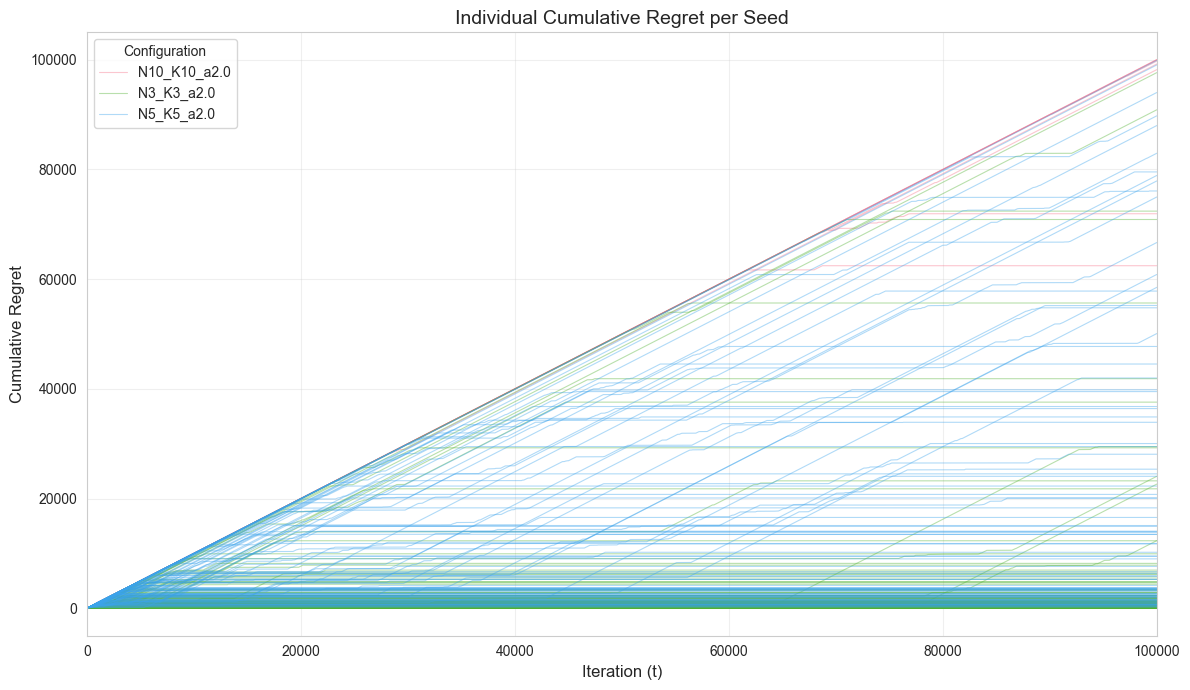

Saved: plots/mean_regret_std.png


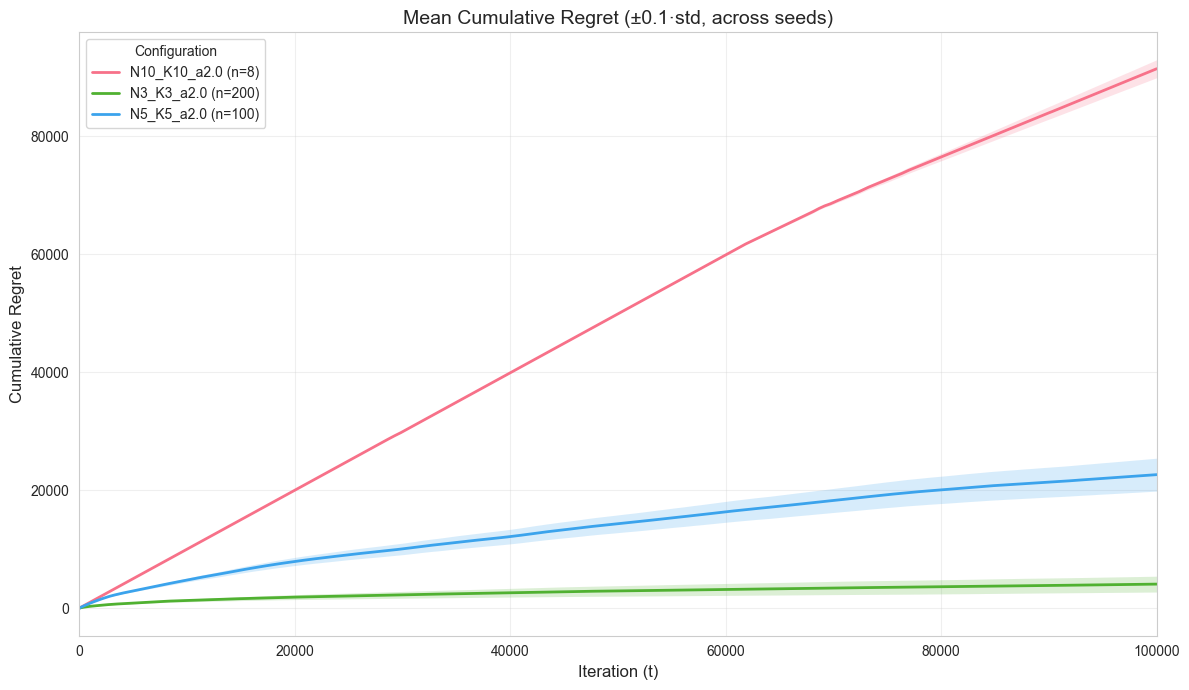

Saved: plots/summary_stats.png


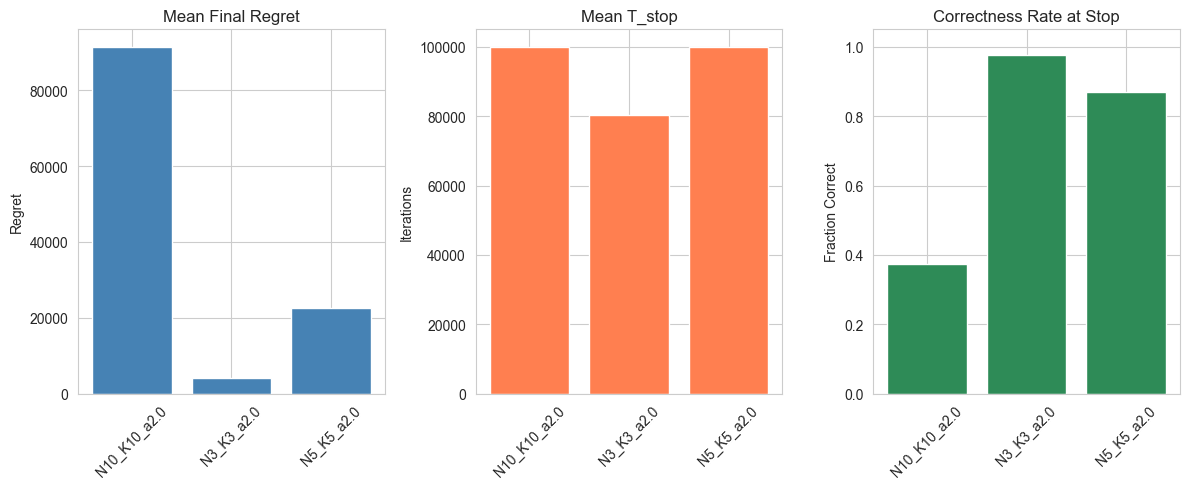

(<Figure size 1200x500 with 3 Axes>,
 array([<Axes: title={'center': 'Mean Final Regret'}, ylabel='Regret'>,
        <Axes: title={'center': 'Mean T_stop'}, ylabel='Iterations'>,
        <Axes: title={'center': 'Correctness Rate at Stop'}, ylabel='Fraction Correct'>],
       dtype=object))

In [15]:
# regret_plotting.py

# import os
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import re

from plotting import *

# ---- CONFIGURE THIS ----
BASE_DIR = "runs"   # <-- change me
MAX_ITERATIONS = 100000
OUTPUT_DIR = "plots"                # where to save figures
# ------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all data
print(f"Scanning {BASE_DIR} ...")
all_data = load_all_configs(BASE_DIR, max_iterations=MAX_ITERATIONS)

if not all_data:
    raise SystemExit("No configuration folders found. Check BASE_DIR.")

print(f"Found {len(all_data)} configurations:")
for cfg, seeds in all_data.items():
    print(f"  {cfg}: {len(seeds)} seeds")

# 1) Individual regret curves
plot_individual_regrets(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "individual_regrets.png"),
)

# 2) Mean ± std regret curves
plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
    std_multiplier=0.1,
    show_individual=False,   # <-- no individual seed lines
)

# 3) Summary stats
plot_summary_stats(
    all_data,
    save_path=os.path.join(OUTPUT_DIR, "summary_stats.png"),
)

Saved: plots/mean_regret_std.png


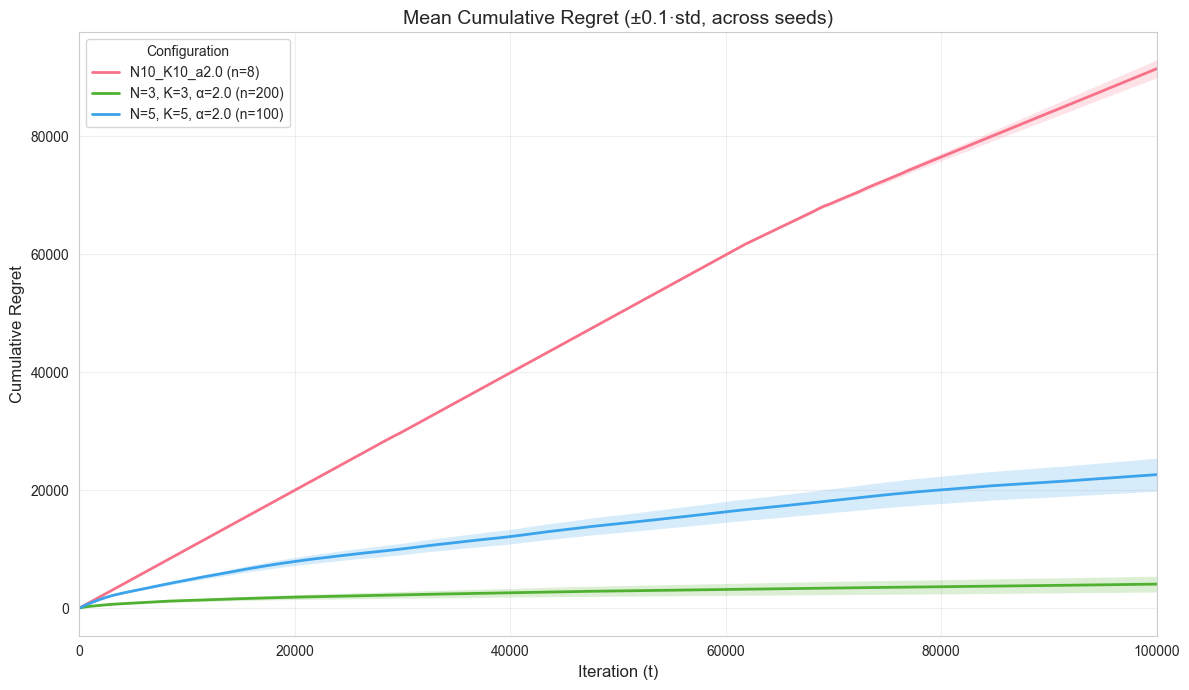

(<Figure size 1200x700 with 1 Axes>,
 <Axes: title={'center': 'Mean Cumulative Regret (±0.1·std, across seeds)'}, xlabel='Iteration (t)', ylabel='Cumulative Regret'>)

In [16]:
LABELS = {
    "N3_K3_a2.0": "N=3, K=3, α=2.0",
    "N5_K5_a2.0": "N=5, K=5, α=2.0",
}

plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    show_individual=False,
    labels=LABELS,
        save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
        std_multiplier=0.1,
)